# Retail Store Sales Data Analysis

## Project Overview

This project analyzes a retail store sales dataset using Python. The workflow includes data cleaning, feature engineering, exploratory data analysis (EDA), and data visualization to prepare the dataset for further analysis and machine learning applications.

### Tools Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Plotly

## Dataset Description

This dataset contains retail store transaction records, including customer information, product categories, item details, quantities, prices, payment methods, locations, discounts, and transaction dates.

The dataset is intentionally imperfect and includes missing values, making it suitable for practicing data cleaning and exploratory data analysis.

## Table of Contents

1. Import Required Libraries
2. Load the Dataset
3. Data Understanding
4. Data Cleaning
5. Feature Engineering
6. Exploratory Data Analysis
7. Data Visualization
8. Export Clean Dataset
9. Conclusion

## 1. Import Required Libraries

The required Python libraries are imported for data manipulation, visualization, and analysis.

In [160]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import warnings
warnings.filterwarnings("ignore")
plt.style.use("ggplot")

## 2. Load the Dataset

The retail sales dataset is loaded into a pandas DataFrame for analysis.

In [161]:
df = pd.read_csv("retail_store_sales.csv")

## 3. Data Understanding

Before cleaning the dataset, it is important to understand its structure. This includes checking the number of rows and columns, data types, summary statistics, column names, and missing values.

In [162]:
df.shape

(12575, 11)

In [163]:
df.isnull().sum()

Transaction ID         0
Customer ID            0
Category               0
Item                1213
Price Per Unit       609
Quantity             604
Total Spent          604
Payment Method         0
Location               0
Transaction Date       0
Discount Applied    4199
dtype: int64

In [164]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    12575 non-null  object 
 1   Customer ID       12575 non-null  object 
 2   Category          12575 non-null  object 
 3   Item              11362 non-null  object 
 4   Price Per Unit    11966 non-null  float64
 5   Quantity          11971 non-null  float64
 6   Total Spent       11971 non-null  float64
 7   Payment Method    12575 non-null  object 
 8   Location          12575 non-null  object 
 9   Transaction Date  12575 non-null  object 
 10  Discount Applied  8376 non-null   object 
dtypes: float64(3), object(8)
memory usage: 1.1+ MB


In [165]:
df.describe()

,Price Per Unit,Quantity,Total Spent
count,11966.000000,11971.000000,11971.000000
mean,23.365912,5.536380,129.652577
std,10.743519,2.857883,94.750697
min,5.000000,1.000000,5.000000
25%,14.000000,3.000000,51.000000
50%,23.000000,6.000000,108.500000
75%,33.500000,8.000000,192.000000
max,41.000000,10.000000,410.000000


In [166]:
df.describe(include="all")

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
count,12575,12575,12575,11362,11966.000000,11971.000000,11971.000000,12575,12575,12575,8376
unique,12575,25,8,200,NaN,NaN,NaN,3,2,1114,2
top,TXN_6867343,CUST_05,Furniture,Item_2_BEV,NaN,NaN,NaN,Cash,Online,2022-05-30,True
freq,1,544,1591,126,NaN,NaN,NaN,4310,6354,26,4219
mean,NaN,NaN,NaN,NaN,23.365912,5.536380,129.652577,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,10.743519,2.857883,94.750697,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,5.000000,1.000000,5.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,14.000000,3.000000,51.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,23.000000,6.000000,108.500000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,33.500000,8.000000,192.000000,NaN,NaN,NaN,NaN


In [167]:
df.isnull().sum()

Transaction ID         0
Customer ID            0
Category               0
Item                1213
Price Per Unit       609
Quantity             604
Total Spent          604
Payment Method         0
Location               0
Transaction Date       0
Discount Applied    4199
dtype: int64

In [168]:
(df.isnull().sum()/len(df))*100

Transaction ID       0.000000
Customer ID          0.000000
Category             0.000000
Item                 9.646123
Price Per Unit       4.842942
Quantity             4.803181
Total Spent          4.803181
Payment Method       0.000000
Location             0.000000
Transaction Date     0.000000
Discount Applied    33.391650
dtype: float64

In [169]:
df.columns

Index(['Transaction ID', 'Customer ID', 'Category', 'Item', 'Price Per Unit',
       'Quantity', 'Total Spent', 'Payment Method', 'Location',
       'Transaction Date', 'Discount Applied'],
      dtype='object')

## 4. Data Cleaning

The dataset contains missing values and inconsistent formatting. In this section, missing values are handled, column names are standardized, and data types are corrected to improve data quality.

In [170]:
df.columns = df.columns.str.lower().str.replace(" ","_")

In [171]:
df.columns

Index(['transaction_id', 'customer_id', 'category', 'item', 'price_per_unit',
       'quantity', 'total_spent', 'payment_method', 'location',
       'transaction_date', 'discount_applied'],
      dtype='object')

In [172]:
df['item'].value_counts()

item
Item_2_BEV      126
Item_25_FUR     113
Item_11_FUR     110
Item_1_MILK     109
Item_16_MILK    109
               ... 
Item_5_BEV        7
Item_13_FUR       7
Item_24_CEA       7
Item_21_PAT       6
Item_3_EHE        5
Name: count, Length: 200, dtype: int64

In [173]:
df['item'].unique()

array(['Item_10_PAT', 'Item_17_MILK', 'Item_12_BUT', 'Item_16_BEV',
       'Item_6_FOOD', nan, 'Item_1_FOOD', 'Item_16_FUR', 'Item_22_BUT',
       'Item_3_BUT', 'Item_2_FOOD', 'Item_24_PAT', 'Item_16_MILK',
       'Item_17_PAT', 'Item_13_EHE', 'Item_7_BEV', 'Item_4_EHE',
       'Item_10_FOOD', 'Item_14_FUR', 'Item_20_BUT', 'Item_25_FUR',
       'Item_14_FOOD', 'Item_22_PAT', 'Item_11_FOOD', 'Item_6_PAT',
       'Item_21_EHE', 'Item_25_BEV', 'Item_23_FOOD', 'Item_10_FUR',
       'Item_11_BEV', 'Item_23_BUT', 'Item_22_BEV', 'Item_10_EHE',
       'Item_24_BUT', 'Item_8_BEV', 'Item_3_FOOD', 'Item_12_FOOD',
       'Item_16_CEA', 'Item_11_PAT', 'Item_16_BUT', 'Item_5_CEA',
       'Item_19_MILK', 'Item_23_FUR', 'Item_7_FUR', 'Item_15_CEA',
       'Item_6_MILK', 'Item_24_CEA', 'Item_22_CEA', 'Item_22_FOOD',
       'Item_2_BUT', 'Item_14_PAT', 'Item_12_PAT', 'Item_18_FOOD',
       'Item_1_PAT', 'Item_4_BEV', 'Item_22_FUR', 'Item_7_PAT',
       'Item_20_CEA', 'Item_20_FOOD', 'Item_11_FUR', 'Item

### 4.1 Handling Missing Values in Item Column

The missing values in the `item` column are replaced using the most frequently occurring item (mode).

In [174]:
df["item"] = df["item"].fillna(df["item"].mode()[0])

In [175]:
df['item'].isnull().sum()

0

### 4.2 Filling Missing Values in Price Per Unit

Missing prices are filled using the median price within each product category to preserve realistic pricing.

In [176]:
df["price_per_unit"] = df.groupby("item")["price_per_unit"].transform(lambda x : x.fillna(x.median()))

### 4.3 Handling Missing Quantity Values

Missing quantities are replaced with the median quantity.

In [177]:
df['quantity'] = df['quantity'].fillna(df['quantity'].median())

### 4.4 Recalculating Total Spent

The `total_spent` column is recalculated using:

Total Spent = Price Per Unit × Quantity

This ensures the values remain consistent after filling missing data.

In [178]:
df['total_spent'] = df['price_per_unit'] * df['quantity']

### 4.5 Handling Missing Discount Information

Missing discount values are treated as `False` and converted into Boolean values.

In [179]:
df['discount_applied']  = df['discount_applied'].fillna("False")

In [180]:
df['discount_applied'] = df['discount_applied'].astype(str).str.lower().map({"true": True,"false":False})

### 4.6 Converting Transaction Date

The transaction date is converted into the datetime format to support time-based analysis.

In [181]:
df['transaction_date'] =  pd.to_datetime(df['transaction_date'])

In [182]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   transaction_id    12575 non-null  object        
 1   customer_id       12575 non-null  object        
 2   category          12575 non-null  object        
 3   item              12575 non-null  object        
 4   price_per_unit    12575 non-null  float64       
 5   quantity          12575 non-null  float64       
 6   total_spent       12575 non-null  float64       
 7   payment_method    12575 non-null  object        
 8   location          12575 non-null  object        
 9   transaction_date  12575 non-null  datetime64[ns]
 10  discount_applied  12575 non-null  bool          
dtypes: bool(1), datetime64[ns](1), float64(3), object(6)
memory usage: 994.8+ KB


In [183]:
df['year'] = df['transaction_date'].dt.year

## 5. Feature Engineering

New features are created from the transaction date to enable monthly, weekly, quarterly, and yearly trend analysis.

In [184]:
df.head()

,transaction_id,customer_id,category,item,price_per_unit,quantity,total_spent,payment_method,location,transaction_date,discount_applied,year
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True,2024
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True,2023
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False,2022
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,False,2022
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False,2022


In [185]:
df["month"] = df["transaction_date"].dt.month_name()

In [186]:
df["day"] = df["transaction_date"].dt.day

In [187]:
df["weekday"] = df["transaction_date"].dt.day_name()

In [188]:
df["quarter"] = df["transaction_date"].dt.quarter

In [189]:
df["weekend"] = (
    df["weekday"]
    .isin(["Saturday","Sunday"])
)
df["weekend"] = df["weekend"].map({True: "Yes",False:"No"})

In [190]:
df["average_price"] = (
    df["total_spent"] /
    df["quantity"]
)

### Preview of the Final Cleaned Dataset

The dataset is displayed after completing data cleaning and feature engineering.

In [191]:
df.head()

,transaction_id,customer_id,category,item,price_per_unit,quantity,total_spent,payment_method,location,transaction_date,discount_applied,year,month,day,weekday,quarter,weekend,average_price
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True,2024,April,8,Monday,2,No,18.5
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True,2023,July,23,Sunday,3,Yes,29.0
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False,2022,October,5,Wednesday,4,No,21.5
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,False,2022,May,7,Saturday,2,Yes,27.5
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False,2022,October,2,Sunday,4,Yes,12.5


# 6. Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is performed to understand the cleaned dataset by analyzing customer behavior, product performance, transaction patterns, and sales trends. This section answers important analytical questions using summary statistics and aggregation techniques.

## 6.1 Dataset Overview

Let's begin by checking the dimensions of the cleaned dataset and reviewing the final data types after cleaning and feature engineering.

In [192]:
df.shape

(12575, 18)

In [193]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   transaction_id    12575 non-null  object        
 1   customer_id       12575 non-null  object        
 2   category          12575 non-null  object        
 3   item              12575 non-null  object        
 4   price_per_unit    12575 non-null  float64       
 5   quantity          12575 non-null  float64       
 6   total_spent       12575 non-null  float64       
 7   payment_method    12575 non-null  object        
 8   location          12575 non-null  object        
 9   transaction_date  12575 non-null  datetime64[ns]
 10  discount_applied  12575 non-null  bool          
 11  year              12575 non-null  int32         
 12  month             12575 non-null  object        
 13  day               12575 non-null  int32         
 14  weekday           1257

## 6.2 Number of Unique Customers

Determine how many unique customers made purchases in the dataset.

In [194]:
df["customer_id"].nunique()

25

## 6.3 Number of Product Categories

Identify the total number of unique product categories available.

In [195]:
df["category"].nunique()

8

## 6.4 Category-wise Transaction Count

Analyze the number of transactions recorded for each product category.

In [196]:
df['category'].value_counts()

category
Furniture                             1591
Electric household essentials         1591
Food                                  1588
Milk Products                         1584
Butchers                              1568
Beverages                             1567
Computers and electric accessories    1558
Patisserie                            1528
Name: count, dtype: int64

## 6.5 Top Selling Items

Identify the products that appear most frequently in customer transactions.

In [197]:
df["item"].value_counts().head(10)

item
Item_2_BEV      1339
Item_25_FUR      113
Item_11_FUR      110
Item_16_MILK     109
Item_1_MILK      109
Item_20_BUT      107
Item_5_FUR       107
Item_14_FOOD     106
Item_11_MILK     106
Item_19_CEA      106
Name: count, dtype: int64

## 6.6 Payment Method Analysis

Determine which payment methods are most commonly used by customers.

In [198]:
df["payment_method"].value_counts()

payment_method
Cash              4310
Digital Wallet    4144
Credit Card       4121
Name: count, dtype: int64

## 6.7 Location-wise Transactions

Analyze the number of transactions across different store locations.

In [199]:
df["location"].value_counts()

location
Online      6354
In-store    6221
Name: count, dtype: int64

## 6.8 Monthly Transactions

Analyze how transaction counts vary across different months.

In [200]:
df['month'].value_counts()

month
January      1361
July         1089
August       1039
June         1038
May          1033
December     1033
September    1021
March        1019
November     1003
April         996
October       978
February      965
Name: count, dtype: int64

## 6.9 Weekday-wise Transactions

Determine which day of the week has the highest number of transactions.

In [201]:
df["weekday"].value_counts()

weekday
Wednesday    1813
Sunday       1811
Friday       1808
Thursday     1790
Tuesday      1788
Saturday     1787
Monday       1778
Name: count, dtype: int64

## 6.10 Revenue by Payment Method

Calculate the total revenue generated by each product category.

In [202]:
df.groupby("payment_method")["total_spent"].sum().sort_values(ascending=False)

payment_method
Cash              563741.0
Digital Wallet    532165.5
Credit Card       530128.0
Name: total_spent, dtype: float64

## 6.11 Top Spending Customers

Identify customers who have spent the highest total amount.

In [203]:
df.groupby("customer_id")["total_spent"].sum().sort_values(ascending=False).head(10)

customer_id
CUST_24    71026.0
CUST_05    69812.5
CUST_08    69781.5
CUST_13    68902.5
CUST_16    67700.5
CUST_23    67505.5
CUST_22    65928.0
CUST_10    65831.5
CUST_15    65613.5
CUST_02    65001.5
Name: total_spent, dtype: float64

## 6.12 Monthly Revenue

Calculate the total revenue generated in each month.

In [204]:
df.groupby("month")["total_spent"].sum()

month
April        131279.5
August       128144.5
December     136545.0
February     126430.5
January      182167.0
July         137963.5
June         135384.0
March        129058.0
May          131011.5
November     129771.5
October      124945.5
September    133334.0
Name: total_spent, dtype: float64

## 6.13 Weekend vs Weekday Transactions

Compare the number of transactions made on weekends and weekdays.

In [205]:
df["weekend"].value_counts()

weekend
No     8977
Yes    3598
Name: count, dtype: int64

## 6.14 Correlation Analysis

Analyze the relationship between numerical variables using a correlation matrix.

In [206]:
df.select_dtypes(include="number").corr()

,price_per_unit,quantity,total_spent,year,day,quarter,average_price
price_per_unit,1.000000,0.011265,0.636999,0.014970,0.003712,-0.003529,1.000000
quantity,0.011265,1.000000,0.709886,-0.010886,0.005430,-0.009980,0.011265
total_spent,0.636999,0.709886,1.000000,0.000340,0.004479,-0.007542,0.636999
year,0.014970,-0.010886,0.000340,1.000000,-0.033466,-0.039348,0.014970
day,0.003712,0.005430,0.004479,-0.033466,1.000000,0.029264,0.003712
quarter,-0.003529,-0.009980,-0.007542,-0.039348,0.029264,1.000000,-0.003529
average_price,1.000000,0.011265,0.636999,0.014970,0.003712,-0.003529,1.000000


## 6.15 Final Dataset Preview

Display the cleaned and feature-engineered dataset before proceeding to visualization.

In [207]:
df.head()

,transaction_id,customer_id,category,item,price_per_unit,quantity,total_spent,payment_method,location,transaction_date,discount_applied,year,month,day,weekday,quarter,weekend,average_price
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True,2024,April,8,Monday,2,No,18.5
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True,2023,July,23,Sunday,3,Yes,29.0
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False,2022,October,5,Wednesday,4,No,21.5
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,False,2022,May,7,Saturday,2,Yes,27.5
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False,2022,October,2,Sunday,4,Yes,12.5


# 7. Data Visualization

Data visualization is performed to present patterns and trends in the dataset in a graphical format. These visualizations help in understanding customer behavior, product performance, revenue distribution, and sales trends more effectively.

In [223]:
import os

os.makedirs("images", exist_ok=True)

## 7.1 Category Distribution

This chart shows the number of transactions across different product categories.

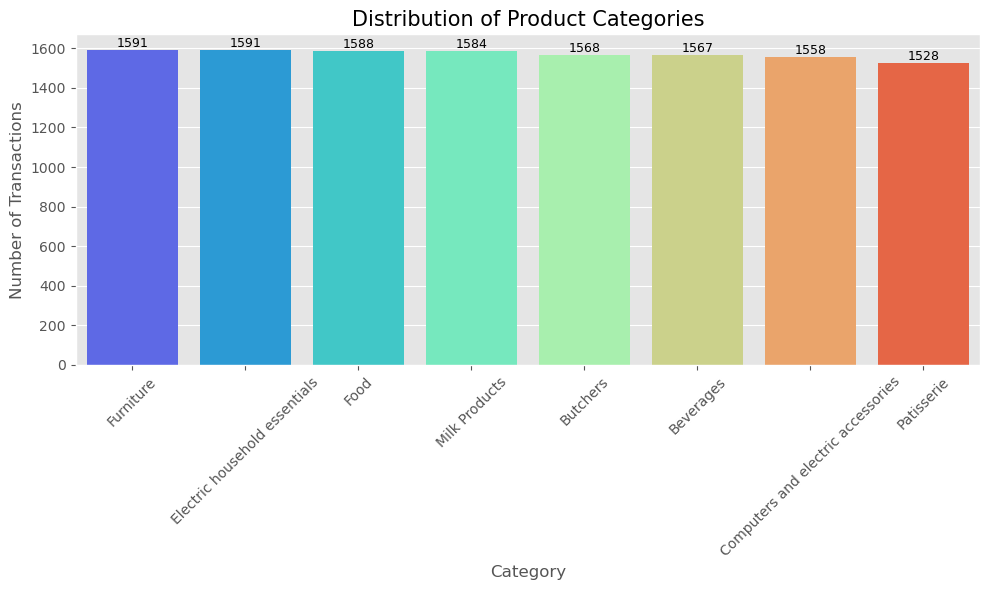

In [226]:
plt.figure(figsize=(10,6))

ax = sns.countplot(
    data=df,
    x="category",
    order=df["category"].value_counts().index,palette='rainbow'
)

for container in ax.containers:
    ax.bar_label(container, fontsize=9)

plt.title("Distribution of Product Categories", fontsize=15)
plt.xlabel("Category")
plt.ylabel("Number of Transactions")

plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig(
    "images/category_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

- Compare the transaction counts across different categories.
- Identify the category with the highest and lowest number of transactions.

## 7.2 Top 10 Selling Products

This bar chart displays the ten most frequently purchased products.

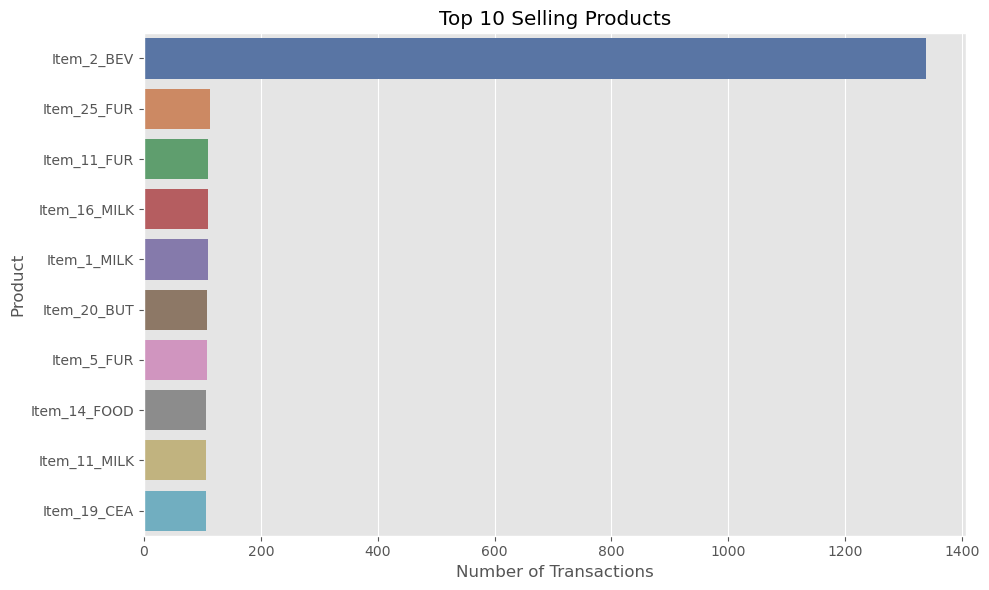

In [227]:
top_products = df["item"].value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_products.values, y=top_products.index,palette='deep')
plt.title("Top 10 Selling Products")
plt.xlabel("Number of Transactions")
plt.ylabel("Product")
plt.tight_layout()
plt.savefig(
    "images/top_10_selling_products.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Observation

- Identify the products with the highest purchase frequency.
- Compare the popularity of the top products.

## 7.3 Payment Method Distribution

The pie chart illustrates the proportion of transactions completed using different payment methods.

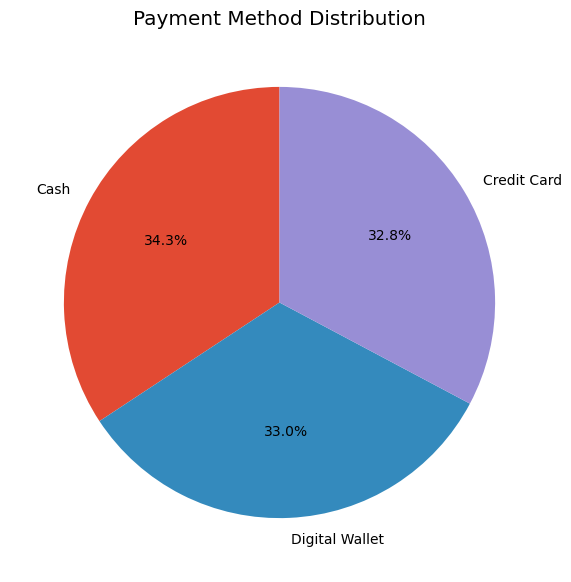

In [228]:
payment = df["payment_method"].value_counts()

plt.figure(figsize=(7,7))
plt.pie(payment,
        labels=payment.index,
        autopct="%1.1f%%",
        startangle=90)

plt.title("Payment Method Distribution")
plt.savefig(
    "images/payment_method_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Observation

- Determine the most commonly used payment method.
- Compare the proportion of each payment method.

## 7.4 Monthly Sales Trend

The line chart shows the total revenue generated in each month.

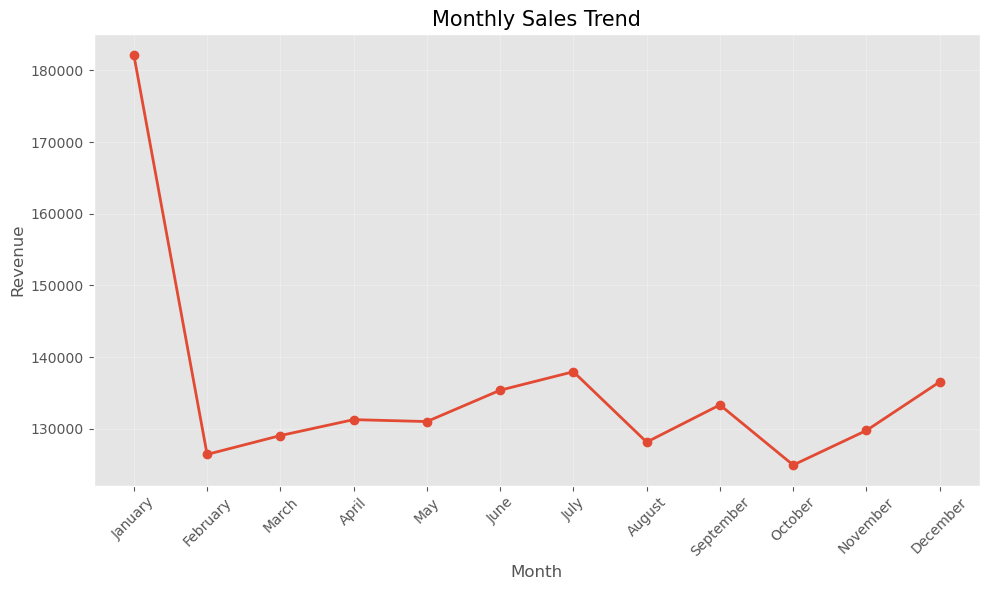

In [229]:
month_order = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]

monthly_sales = (
    df.groupby("month")["total_spent"]
      .sum()
      .reindex(month_order)
)
plt.figure(figsize=(10,6))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker="o",
    linewidth=2
)

plt.title("Monthly Sales Trend", fontsize=15)
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.xticks(rotation=45)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(
    "images/monthly_sales_trend.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Observation

- Identify months with peak sales.
- Observe fluctuations in monthly revenue.

## 7.5 Revenue by Category

This bar chart compares the total revenue generated by each product category.

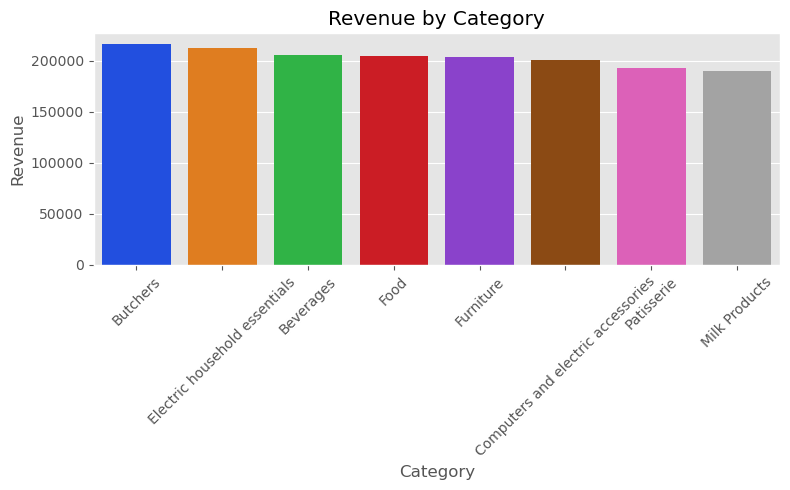

In [230]:
category_sales = df.groupby("category")["total_spent"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=category_sales.index,
            y=category_sales.values,palette='bright')

plt.title("Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(
    "images/revenue_by_category.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Observation

- Compare the revenue contribution of each category.
- Identify the highest revenue-generating category.

## 7.6 Revenue Distribution

The histogram shows how the total amount spent is distributed across all transactions.

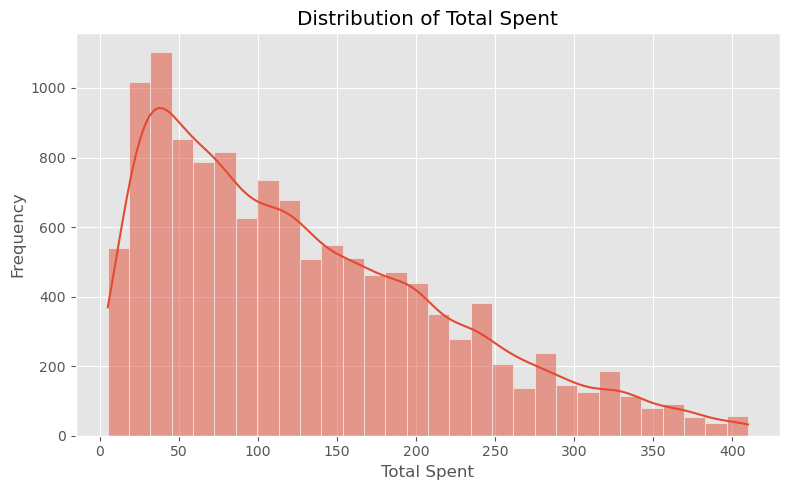

In [231]:
plt.figure(figsize=(8,5))
sns.histplot(df["total_spent"],
             bins=30,
             kde=True,palette='rainbow')

plt.title("Distribution of Total Spent")
plt.xlabel("Total Spent")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(
    "images/revenue_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Observation

- Observe whether the distribution is symmetric or skewed.
- Identify the range where most transactions occur.

## 7.7 Revenue by Location

This horizontal bar chart compares the total revenue generated at different store locations.

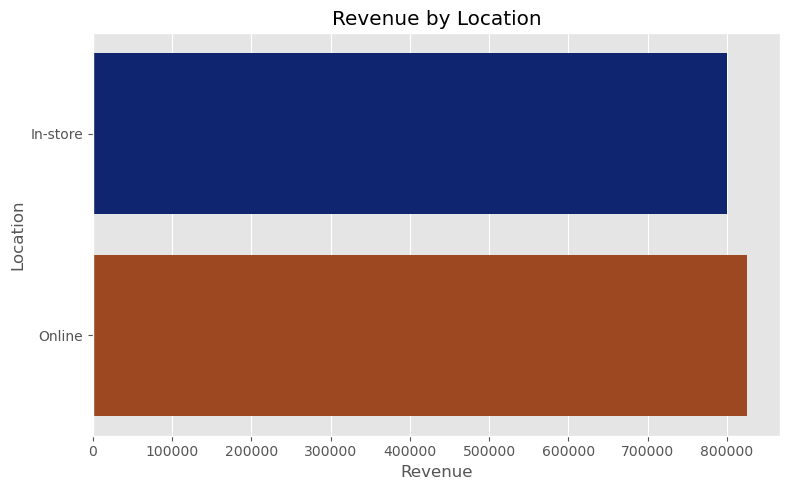

In [232]:
location_sales = df.groupby("location")["total_spent"].sum().sort_values()

plt.figure(figsize=(8,5))
sns.barplot(x=location_sales.values,
            y=location_sales.index,palette='dark')

plt.title("Revenue by Location")
plt.xlabel("Revenue")
plt.ylabel("Location")
plt.tight_layout()
plt.savefig(
    "images/revenue_by_location.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

- Compare revenue generated by each location.
- Identify the highest-performing location.

## 7.8 Correlation Heatmap

The heatmap displays the correlation between numerical variables in the dataset.

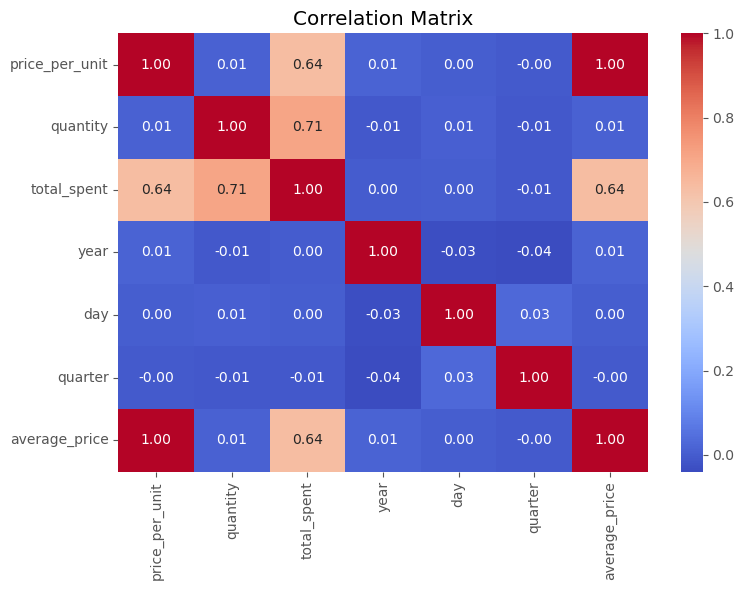

In [233]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.select_dtypes(include="number").corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.savefig(
    "images/correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Observation

- Identify variables with strong positive or negative correlations.
- Determine whether any features are highly related.

## 7.9 Total Spent Distribution

The box plot helps identify the spread of transaction amounts and detect potential outliers.

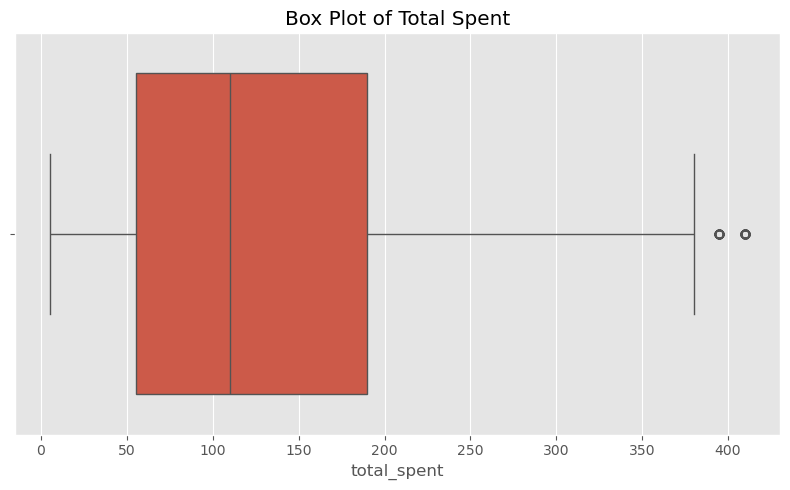

In [234]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["total_spent"])

plt.title("Box Plot of Total Spent")
plt.tight_layout()
plt.savefig(
    "images/total_spent_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Observation

- Observe the spread of transaction values.
- Check for possible outliers.

## 7.10 Price Per Unit vs Total Spent

The scatter plot illustrates the relationship between product price and total spending.

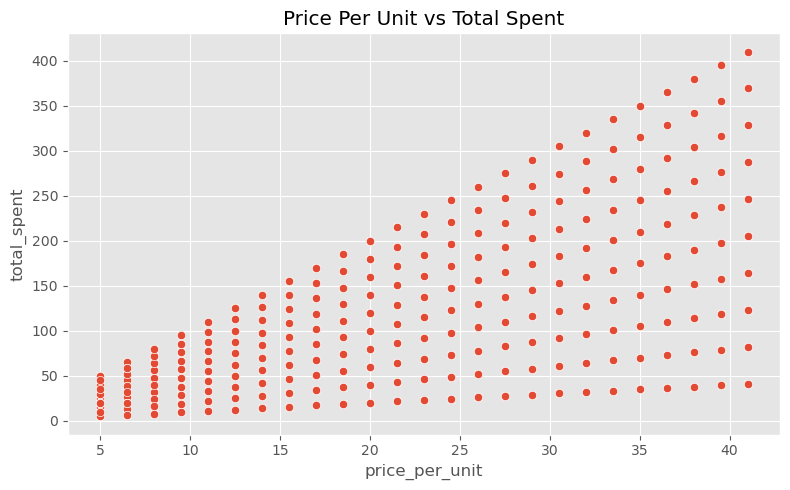

In [235]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="price_per_unit",
    y="total_spent"
)

plt.title("Price Per Unit vs Total Spent")
plt.tight_layout()
plt.savefig(
    "images/price_vs_total_spent.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Observation

- Observe the relationship between price and total spending.
- Identify any unusual patterns or outliers.

## 7.11 Revenue Distribution by Category

The violin plot displays the distribution of transaction amounts across product categories.

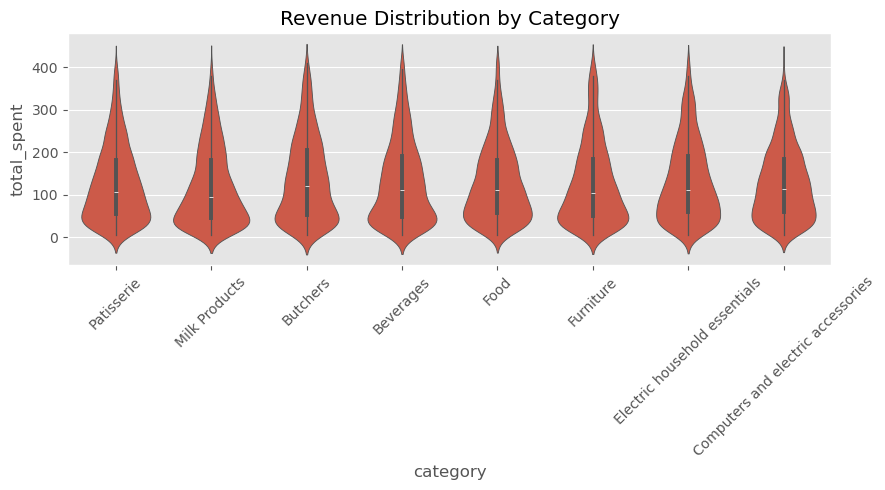

In [236]:
plt.figure(figsize=(9,5))

sns.violinplot(
    data=df,
    x="category",
    y="total_spent"
)

plt.xticks(rotation=45)
plt.title("Revenue Distribution by Category")
plt.tight_layout()
plt.savefig(
    "images/revenue_distribution_by_category.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

- Compare the spread of revenue across categories.
- Observe differences in variability.

## 7.12 Pairwise Relationship Between Numerical Features

The pair plot helps visualize relationships and distributions among numerical variables.

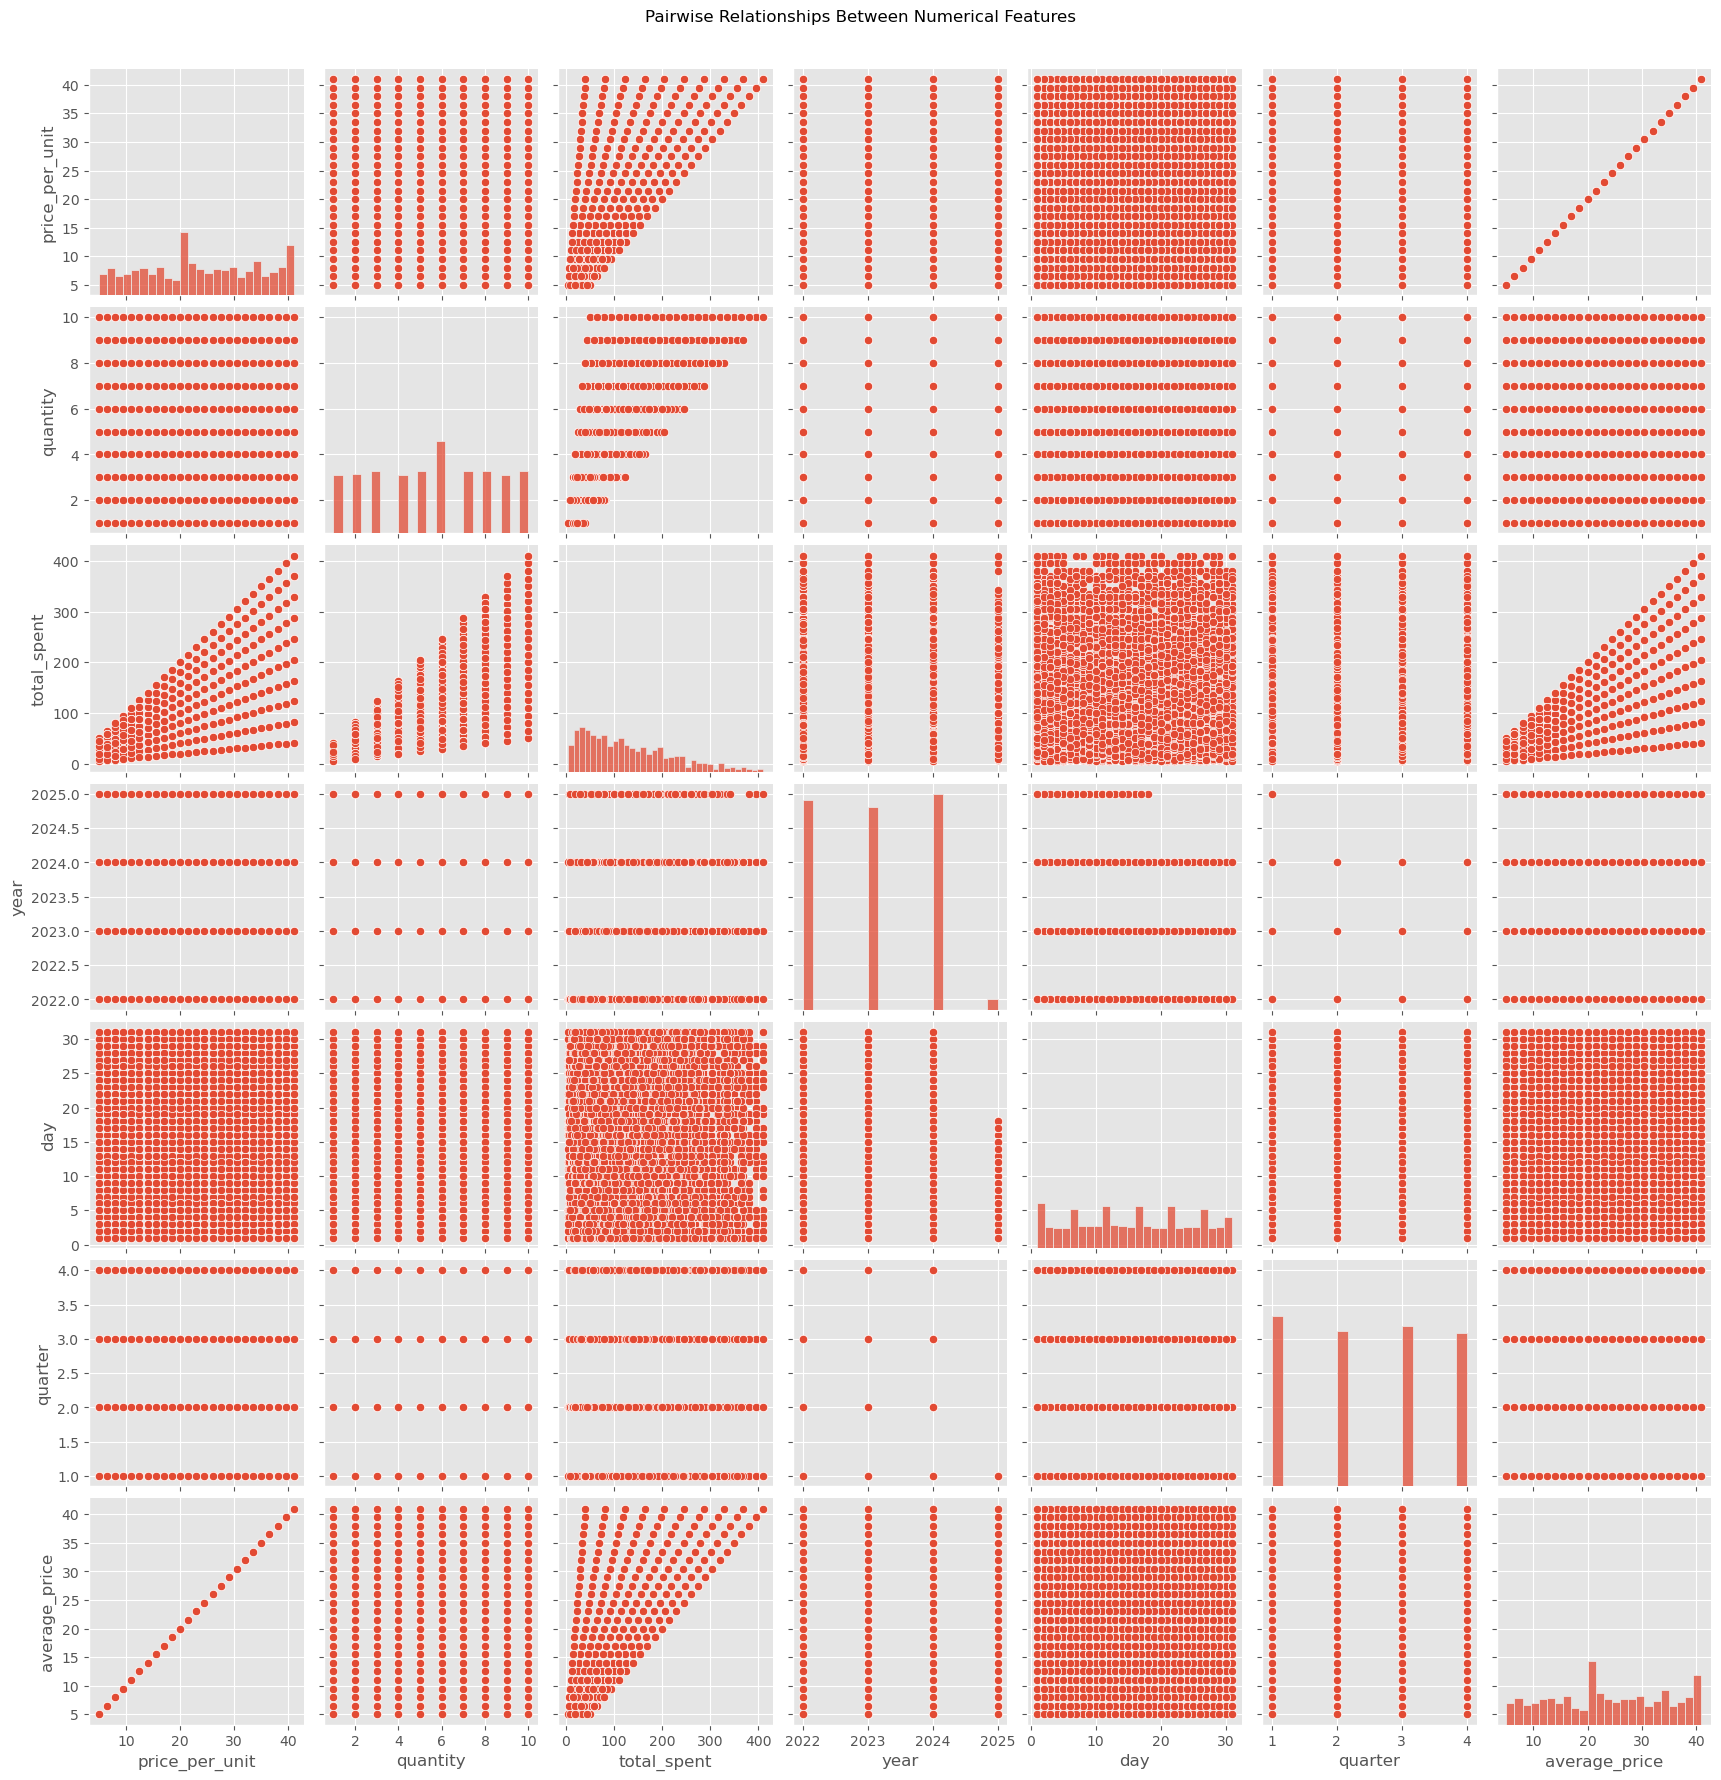

In [238]:
pair_plot = sns.pairplot(
    df.select_dtypes(include="number")
)

pair_plot.figure.suptitle(
    "Pairwise Relationships Between Numerical Features",
    y=1.02
)

pair_plot.savefig(
    "images/pair_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

- Examine relationships between numerical variables.
- Identify clusters or potential correlations.

# 8. Export Clean Dataset

In [222]:
df.to_csv("clean_retail_store_sales.csv", index=False)

# 9. Conclusion

This project demonstrates a complete data analytics workflow using a retail sales dataset.

### Tasks Completed

- Imported and explored the dataset
- Cleaned missing and inconsistent data
- Standardized column names
- Performed feature engineering
- Conducted exploratory data analysis
- Built multiple visualizations
- Exported the cleaned dataset

### Skills Demonstrated

- Python
- Pandas
- NumPy
- Data Cleaning
- Feature Engineering
- Exploratory Data Analysis
- Data Visualization
- Matplotlib
- Seaborn

The cleaned dataset is now ready for further business analysis or machine learning applications.